# Rigorous logical-error bounds for a stim circuit

`lcd-qec` computes **rigorous upper bounds** on the per-shot logical failure probability of minimum-weight matching
(pymatching) on any balanced stim detector error model, and therefore also of the maximum-likelihood decoder.
Sampling gives an estimate with error bars; the bound is a guarantee (theory notes, Theorems 4.28, 4.32, 4.34).

In [1]:
import stim
from lcd.analysis.circuit_peierls_geodesic import best_bound

def circuit(d, p):
    return stim.Circuit.generated("surface_code:rotated_memory_z", distance=d, rounds=d,
                                  after_clifford_depolarization=p, after_reset_flip_probability=p,
                                  before_measure_flip_probability=p, before_round_data_depolarization=p)

dem = circuit(5, 1e-3).detector_error_model(decompose_errors=True)
r = best_bound(dem)
print(f"p_L <= {r['bound']:.3e}   (Theorem {r['method']}, lambda = {r['lam']})")

p_L <= 2.000e-03   (Theorem 4.34, lambda = 0.5)


## Next to a sinter run
`compare` adds the bound to every sinter result of a covered decoder and flags any sampled rate that is significantly
above it (that would falsify the theorem or the implementation).

In [2]:
import sinter
from lcd.integrations.sinter_peierls import compare

tasks = [sinter.Task(circuit=circuit(d, 2e-3), json_metadata={"d": d}) for d in (3, 5)]
stats = sinter.collect(num_workers=2, tasks=tasks, decoders=["pymatching"], max_shots=200_000, max_errors=300)
for row in sorted(compare(tasks, stats), key=lambda r: r["json_metadata"]["d"]):
    print(f"d={row['json_metadata']['d']}: sampled {row['rate']:.2e}  bound {row['bound']:.2e}  "
          f"({row['ratio']:.0f}x, consistent: {row['consistent']})")

d=3: sampled 2.67e-03  bound 1.98e-02  (7x, consistent: True)
d=5: sampled 1.13e-03  bound 1.58e-02  (14x, consistent: True)


## The bound against distance

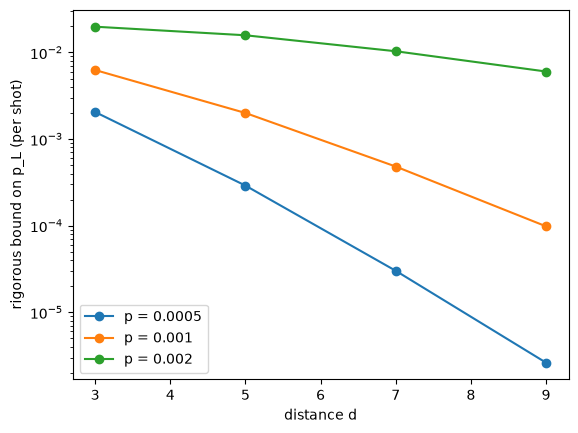

In [3]:
import matplotlib.pyplot as plt
ds = [3, 5, 7, 9]
for p in (5e-4, 1e-3, 2e-3):
    plt.semilogy(ds, [best_bound(circuit(d, p).detector_error_model(decompose_errors=True))["bound"] for d in ds],
                 "o-", label=f"p = {p:g}")
plt.xlabel("distance d"); plt.ylabel("rigorous bound on p_L (per shot)"); plt.legend(); plt.show()

The same from the command line:

```
lcd-peierls --generated surface_code:rotated_memory_z -d 5 -p 1e-3
lcd-peierls my_circuit.stim other_model.dem --json
```